# What data is there, and how clean is it?

**In short.** Three markets are followed: Bitcoin, gold (as PAX Gold, a coin backed
by gold) and US stocks. Their daily returns have far more very large days than a bell
curve allows, and large days follow large days. Those two facts decide the methods
used everywhere else: ranges are drawn from real past days, and the size of the next
movement is forecast while its direction is not.

| Step | What it shows | Code | Why it matters later |
|---|---|---|---|
| 1 | How much history there is, and what is missing | `radar.pipelines.profile` | Every figure in the app states its period |
| 2 | Returns have more extreme days than a bell curve | `radar.pipelines.profile` | Ranges are drawn from real days (`02`, `05`) |
| 3 | Rough days come in stretches | `radar.pipelines.datasets` | Market states and the movement forecast (`02`, `03`) |
| 4 | How the three move together, and how that changes | `radar.pipelines.datasets` | Where a mix's risk sits (`05`) |
| 5 | How much news there is | `radar.db.models` | Tone is only an average of many articles (`04`) |

Every table comes from the code that writes `docs/DATA_PROFILE.md`. Times are UTC.

Rebuild with `uv run python backend/scripts/build_notebooks.py 01_exploration`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import select

from radar.db.models import NewsArticle, NewsSymbol
from radar.db.session import make_engine, session_scope
from radar.notebooks import ACCENT, INK, MUTED, use_style
from radar.pipelines import profile as profiling
from radar.pipelines.datasets import build_mixed_panel, build_realised_volatility, load_field, stock_daily
from radar.universe import get_universe

use_style()
engine, universe = make_engine(), get_universe()
MARKETS = {asset.symbol: asset.name.split(" (")[0] for asset in universe.primary}
COLOURS = dict(zip(MARKETS, ("#e8843c", "#c9952b", ACCENT)))
profile = profiling.build_profile(engine, universe)

closes, returns, movement = {}, {}, {}
with session_scope(engine) as session:
    for asset in universe.primary:
        load = load_field(session, [asset.symbol], "1Day") if asset.asset_class == "crypto" else stock_daily(session, [asset.symbol])
        closes[asset.symbol] = load[asset.symbol].dropna()
        returns[asset.symbol] = profiling.daily_returns(session, asset)
        movement[asset.symbol] = build_realised_volatility(session, asset)["rv"].dropna()
    together = build_mixed_panel(session, universe).returns[list(MARKETS)].dropna()
    links = session.execute(
        select(NewsSymbol.symbol, NewsArticle.created_at)
        .join(NewsArticle, NewsArticle.id == NewsSymbol.article_id)
        .where(NewsSymbol.symbol.in_(list(MARKETS)))
    ).all()
for symbol, name in MARKETS.items():
    print(f"{name}: {len(closes[symbol]):,} daily prices, {closes[symbol].index[0].date()} to {closes[symbol].index[-1].date()}")

Bitcoin: 2,105 daily prices, 2021-01-01 to 2026-10-06
Gold: 2,105 daily prices, 2021-01-01 to 2026-10-06
US stocks: 2,705 daily prices, 2016-01-04 to 2026-10-06


## Step 1. How much history, and what is missing

In [2]:
stored = profile.coverage[profile.coverage["symbol"].isin(MARKETS)].copy()
stored["market"] = stored["symbol"].map(MARKETS)
stored["missing, %"] = stored["missing_share"] * 100
stored["first"], stored["last"] = stored["first"].dt.date, stored["last"].dt.date
stored = stored.rename(columns={"timeframe": "prices", "bars": "stored"}).replace({"1Hour": "hourly", "1Day": "daily"})
stored.set_index(["market", "prices"])[["first", "last", "stored", "missing", "missing, %"]]

first        last  stored  missing  missing, %
market    prices                                                     
Bitcoin   hourly  2021-01-01  2026-10-07   50507       27        0.05
          daily   2021-01-01  2026-10-06    2105        0        0.00
Gold      hourly  2021-01-01  2026-10-07   48533     2001        3.96
          daily   2021-01-01  2026-10-06    2105        0        0.00
US stocks hourly  2016-01-04  2026-10-07   42581        0        0.00
          daily   2016-01-04  2026-10-06    2705        0        0.00

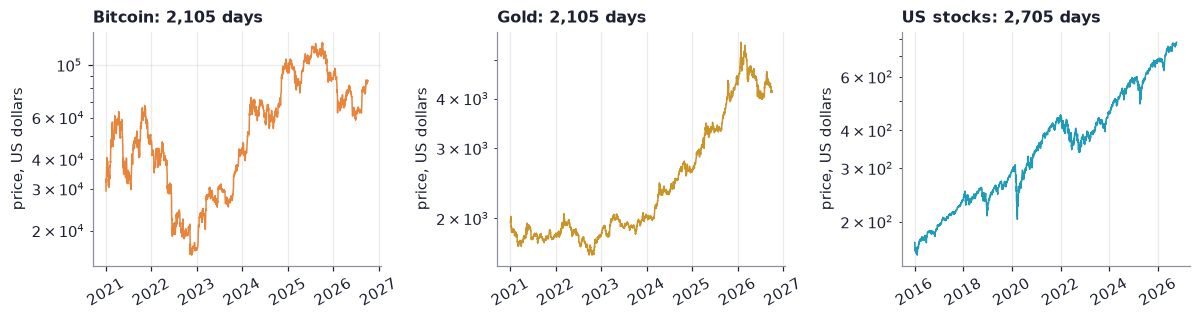

In [3]:
fig, axes = plt.subplots(1, len(MARKETS), figsize=(11, 3))
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    ax.plot(closes[symbol].index, closes[symbol].values, color=COLOURS[symbol], lw=1)
    ax.set(title=f"{name}: {len(closes[symbol]):,} days", yscale="log", ylabel="price, US dollars")
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

Bitcoin and gold start in 2021, US stocks in 2016. Anything learned about the first
two comes from few market cycles, which the later notebooks repeat where it matters.

**Gold's hourly prices have gaps.** PAX Gold is thinly traded at some hours, and an
hour with no trade has no price. The table above counts them. Daily prices are
complete, so anything built on days is unaffected; the size of a day's movement is
built from hours, and step 3 counts the days on which too many were missing.

## Step 2. More extreme days than a bell curve allows

Bars are the returns that happened. The line is a bell curve with the same average
and spread. The scale is logarithmic so the rare days at the edges can be seen: the
bars sit well above the line there. "Today tied to yesterday" in the second table is
small in every market: a day's direction says little about the next.

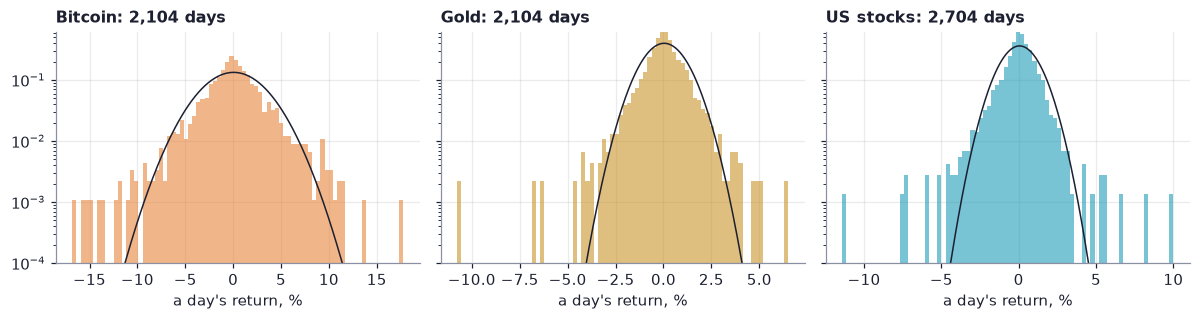

In [4]:
fig, axes = plt.subplots(1, len(MARKETS), figsize=(11, 3), sharey=True)
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    r = returns[symbol]
    ax.hist(r * 100, bins=80, density=True, color=COLOURS[symbol], alpha=0.6)
    x = np.linspace(r.min(), r.max(), 300)
    bell = np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2) / (r.std() * np.sqrt(2 * np.pi))
    ax.plot(x * 100, bell / 100, color=INK, lw=1)
    ax.set(title=f"{name}: {len(r):,} days", xlabel="a day's return, %", yscale="log", ylim=(1e-4, None))
fig.tight_layout()

In [5]:
# How many days were more than three usual-sized moves from the average, beside how
# many a bell curve would give (about 0.27% of days).
rows = {}
for symbol, name in MARKETS.items():
    r = returns[symbol]
    far = int((np.abs(r - r.mean()) > 3 * r.std()).sum())
    rows[name] = {"days": len(r), "extreme days": far, "a bell curve would give": round(len(r) * 0.0027, 1)}
extremes = pd.DataFrame(rows).T
extremes["times as many"] = extremes["extreme days"] / extremes["a bell curve would give"]
extremes

,days,extreme days,a bell curve would give,times as many
Bitcoin,"2,104.00",43.00,5.70,7.54
Gold,"2,104.00",32.00,5.70,5.61
US stocks,"2,704.00",39.00,7.30,5.34


In [6]:
shape = profile.returns[profile.returns["symbol"].isin(MARKETS)].set_index("symbol").rename(index=MARKETS)
pd.DataFrame(
    {
        "days": shape["days"],
        "movement in a year, %": shape["annual_volatility"] * 100,
        "worst day, %": shape["worst"] * 100,
        "best day, %": shape["best"] * 100,
        "today tied to yesterday": shape["autocorr_1"],
        "size today tied to size yesterday": shape["squared_autocorr_1"],
    }
).round(2)

,days,"movement in a year, %","worst day, %","best day, %",today tied to yesterday,size today tied to size yesterday
symbol,,,,,,
Bitcoin,2104,57.15,-16.80,17.75,-0.04,0.15
Gold,2104,19.07,-10.76,6.50,-0.03,0.13
US stocks,2704,17.49,-11.41,9.98,-0.12,0.33


## Step 3. Rough days come in stretches

How strongly the size of one day's movement is tied to the size of the movement some
days later. Bars that stay above zero mean large days follow large days.

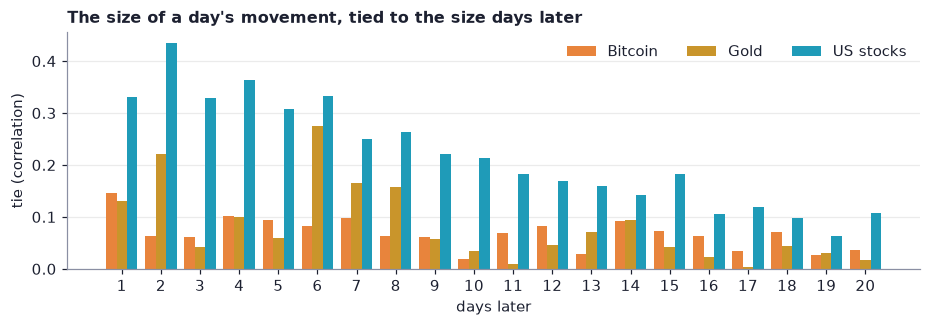

In [7]:
later = np.arange(1, 21)
fig, ax = plt.subplots(figsize=(10, 2.8))
width = 0.8 / len(MARKETS)
for index, (symbol, name) in enumerate(MARKETS.items()):
    squared = returns[symbol] ** 2
    ax.bar(later + (index - (len(MARKETS) - 1) / 2) * width, [squared.autocorr(lag) for lag in later], width, color=COLOURS[symbol], label=name)
ax.set(title="The size of a day's movement, tied to the size days later", xlabel="days later", ylabel="tie (correlation)", xticks=later)
ax.grid(axis="x", visible=False)
ax.legend(ncol=3);

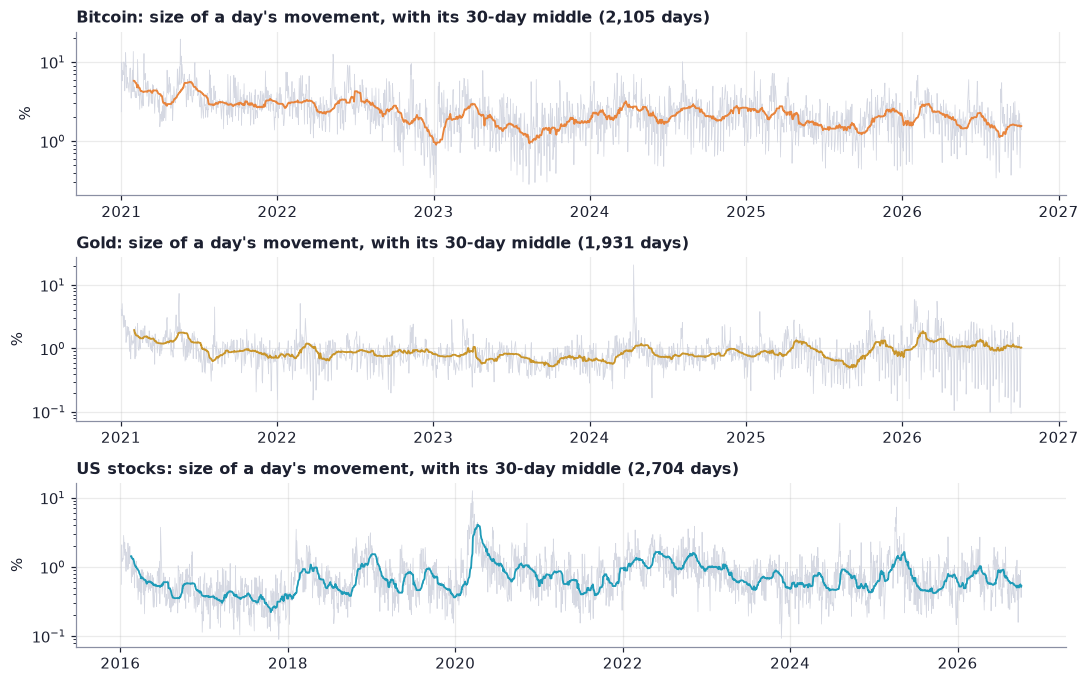

In [8]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(10, 2.1 * len(MARKETS)))
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    size = movement[symbol] * 100
    ax.plot(size.index, size.values, color="#d5d8e2", lw=0.5)
    ax.plot(size.index, size.rolling(30).median().values, color=COLOURS[symbol], lw=1.2)
    ax.set(title=f"{name}: size of a day's movement, with its 30-day middle ({len(size):,} days)", ylabel="%", yscale="log")
fig.tight_layout()

In [9]:
sizes = profile.volatility[profile.volatility["symbol"].isin(MARKETS)].set_index("symbol").rename(index=MARKETS)
pd.DataFrame(
    {
        "days": sizes["days"],
        "days with too many hours missing": sizes["flagged"],
        "that is, %": sizes["flagged_share"] * 100,
        "usual day, %": sizes["median"] * 100,
        "1 day in 20 is above, %": sizes["p95"] * 100,
        "largest, %": sizes["max"] * 100,
    }
).round(2)

,days,days with too many hours missing,"that is, %","usual day, %","1 day in 20 is above, %","largest, %"
symbol,,,,,,
Bitcoin,2106,1,0.05,2.26,5.59,19.46
Gold,2106,175,8.31,0.87,2.02,20.81
US stocks,2705,1,0.04,0.66,1.93,12.63


## Step 4. How they move together

Measured on days the US stock market was open, with weekend moves of Bitcoin and gold
folded into Monday so that every column describes the same days. Each line is one
pair, over the previous 90 trading days.

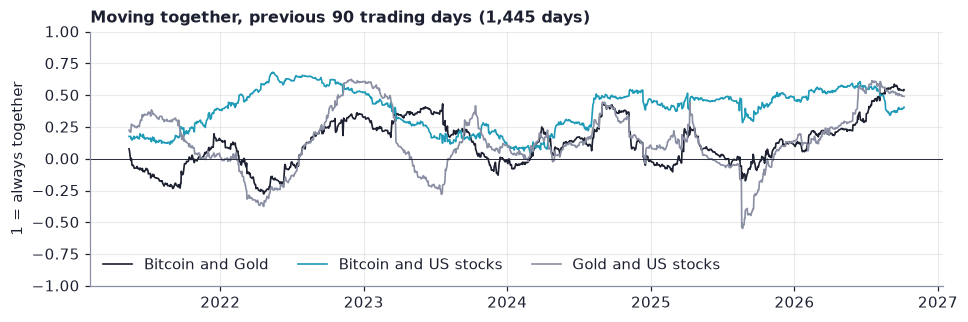

In [10]:
pairs = [(a, b) for index, a in enumerate(MARKETS) for b in list(MARKETS)[index + 1 :]]
fig, ax = plt.subplots(figsize=(10, 3))
for (a, b), colour in zip(pairs, (INK, ACCENT, MUTED)):
    rolling = together[a].rolling(90).corr(together[b]).dropna()
    ax.plot(rolling.index, rolling.values, color=colour, lw=1.1, label=f"{MARKETS[a]} and {MARKETS[b]}")
ax.axhline(0, color=INK, lw=0.6)
ax.set(title=f"Moving together, previous 90 trading days ({len(together):,} days)", ylim=(-1, 1), ylabel="1 = always together")
ax.legend(ncol=3, loc="lower left");

In [11]:
whole = together.corr().rename(index=MARKETS, columns=MARKETS)
for a, b in pairs:
    rolling = together[a].rolling(90).corr(together[b]).dropna()
    print(f"{MARKETS[a]} and {MARKETS[b]}: {whole.loc[MARKETS[a], MARKETS[b]]:+.2f} over the whole period, between {rolling.min():+.2f} and {rolling.max():+.2f} in single 90-day stretches")

Bitcoin and Gold: +0.12 over the whole period, between -0.28 and +0.59 in single 90-day stretches
Bitcoin and US stocks: +0.39 over the whole period, between +0.04 and +0.68 in single 90-day stretches
Gold and US stocks: +0.14 over the whole period, between -0.55 and +0.63 in single 90-day stretches


The spread printed above is the point: one number for "how they move together" hides
a wide range, so every such figure in the app states the days it was measured on.

## Step 5. How much news

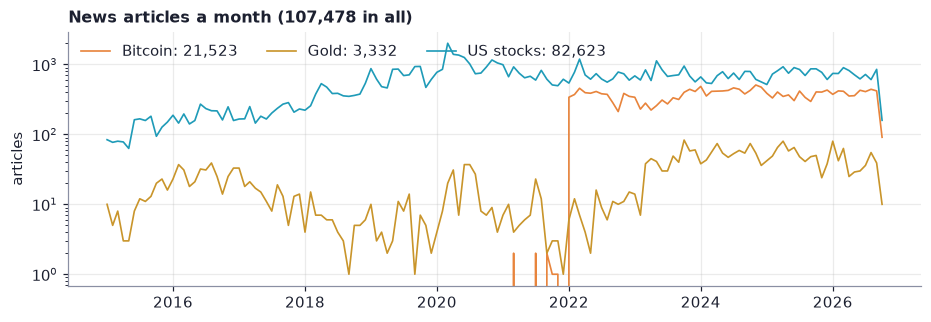

In [12]:
news = pd.DataFrame(links, columns=["symbol", "created_at"])
news["month"] = pd.to_datetime(news["created_at"], utc=True).dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
monthly = news.groupby(["month", "symbol"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3))
for symbol, name in MARKETS.items():
    if symbol in monthly:
        ax.plot(monthly.index, monthly[symbol].values, color=COLOURS[symbol], lw=1.1, label=f"{name}: {int(monthly[symbol].sum()):,}")
ax.set(title=f"News articles a month ({len(news):,} in all)", yscale="log", ylabel="articles")
ax.legend(ncol=3);

Gold has far less news than the other two. Its articles are the ones written about
the gold fund, read for PAX Gold, because the coin has almost none of its own.

## What to take from this

- Extreme days are several times more common than a bell curve gives (the table in
  step 2), so a range built on a bell curve understates the worst days.
- Rough days come in stretches, so the size of the next movement can be forecast.
  Nothing here says the same about its direction.
- How the markets move together changes a great deal from one stretch to the next.
- Two of the three markets have under six years of prices.
- Gold as PAX Gold trades around the clock, which the fund did not, at the cost of
  hours with no trade: the last table counts the days that affects.